# Import Libraries

In [1]:
# Basic
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, r2_score,
    mean_squared_error, mean_absolute_error
)

# Models
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics.pairwise import cosine_similarity

# Save Models
import pickle

import warnings
warnings.filterwarnings("ignore")

# Load Data

In [2]:
transaction = pd.read_excel("Transaction.xlsx")
users = pd.read_excel("User.xlsx")
mode = pd.read_excel("Mode.xlsx")
region = pd.read_excel("Region.xlsx")
type_df = pd.read_excel("Type.xlsx")
item = pd.read_excel("Item.xlsx")
city = pd.read_excel("City.xlsx")
country = pd.read_excel("Country.xlsx")
continent = pd.read_excel("Continent.xlsx")

# Data Cleaning

In [3]:
# cleaning dummy rows ID = 0
tables = [item, type_df, city, country, region, continent]

for t in tables:
    id_col = [c for c in t.columns if "Id" in c][0]
    t.drop(t[t[id_col] == 0].index, inplace=True)

In [4]:
print("Transaction", transaction.columns)
print("-------------------------------------------")
print("Users", users.columns)
print("-------------------------------------------")
print("Mode", mode.columns)
print("-------------------------------------------")
print("Region", region.columns)
print("-------------------------------------------")
print("Attraction", type_df.columns)
print("-------------------------------------------")
print("Item", item.columns)
print("-------------------------------------------")
print("City", city.columns)
print("-------------------------------------------")
print("Country", country.columns)
print("-------------------------------------------")
print("Continent", continent.columns)

Transaction Index(['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode',
       'AttractionId', 'Rating'],
      dtype='object')
-------------------------------------------
Users Index(['UserId', 'ContinentId', 'RegionId', 'CountryId', 'CityId'], dtype='object')
-------------------------------------------
Mode Index(['VisitModeId', 'VisitMode'], dtype='object')
-------------------------------------------
Region Index(['Region', 'RegionId', 'ContinentId'], dtype='object')
-------------------------------------------
Attraction Index(['AttractionTypeId', 'AttractionType'], dtype='object')
-------------------------------------------
Item Index(['AttractionId', 'AttractionCityId', 'AttractionTypeId', 'Attraction',
       'AttractionAddress'],
      dtype='object')
-------------------------------------------
City Index(['CityId', 'CityName', 'CountryId'], dtype='object')
-------------------------------------------
Country Index(['CountryId', 'Country', 'RegionId'], dtype='object

In [5]:
# First rename transaction VisitMode → VisitModeId
transaction = transaction.rename(columns={'VisitMode': 'VisitModeId'})

# Merge to get readable VisitMode
transaction = transaction.merge(
    mode,
    on="VisitModeId",
    how="left"
)

# Now you have:
#   VisitModeId
#   VisitMode (readable)

In [6]:
transaction.columns

Index(['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitModeId',
       'AttractionId', 'Rating', 'VisitMode'],
      dtype='object')

#### Users → City → Country → Region → Continent

In [7]:
# Merge Users into Transaction
master = transaction.merge(users, on="UserId", how="left")

In [8]:
master.columns

Index(['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitModeId',
       'AttractionId', 'Rating', 'VisitMode', 'ContinentId', 'RegionId',
       'CountryId', 'CityId'],
      dtype='object')

In [9]:
# City
master = master.merge(
    city[['CityId', 'CityName', 'CountryId']],
    on="CityId",
    how="left",
    suffixes=("", "_city")
)

In [10]:
master.columns

Index(['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitModeId',
       'AttractionId', 'Rating', 'VisitMode', 'ContinentId', 'RegionId',
       'CountryId', 'CityId', 'CityName', 'CountryId_city'],
      dtype='object')

CountryId comes from users and CountryId_city comes from city

The correct CountryId should come from City table, not Users.

Keep CountryId_city

Drop CountryId

Rename CountryId_city → CountryId

In [11]:
# Drop wrong CountryId (from Users)
master = master.drop(columns=["CountryId"])

# Rename correct CountryId_city
master = master.rename(columns={"CountryId_city": "CountryId"})

In [12]:
master.columns

Index(['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitModeId',
       'AttractionId', 'Rating', 'VisitMode', 'ContinentId', 'RegionId',
       'CityId', 'CityName', 'CountryId'],
      dtype='object')

In [13]:
# Country
# Since Users already has CountryId, it’s safer to merge using that.
master = master.merge(
    country[['CountryId', 'Country', 'RegionId']],
    on="CountryId",
    how="left",
    suffixes=("", "_country")
)

In [14]:
master.columns

Index(['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitModeId',
       'AttractionId', 'Rating', 'VisitMode', 'ContinentId', 'RegionId',
       'CityId', 'CityName', 'CountryId', 'Country', 'RegionId_country'],
      dtype='object')

In [15]:
# Drop wrong RegionId (from Users)
master = master.drop(columns=["RegionId"])

# Rename correct RegionId_country
master = master.rename(columns={"RegionId_country": "RegionId"})

In [16]:
master.columns

Index(['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitModeId',
       'AttractionId', 'Rating', 'VisitMode', 'ContinentId', 'CityId',
       'CityName', 'CountryId', 'Country', 'RegionId'],
      dtype='object')

In [17]:
# Region
master = master.merge(
    region[['RegionId', 'Region', 'ContinentId']],
    on="RegionId",
    how="left",
    suffixes=("", "_region")
)

In [18]:
master.columns

Index(['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitModeId',
       'AttractionId', 'Rating', 'VisitMode', 'ContinentId', 'CityId',
       'CityName', 'CountryId', 'Country', 'RegionId', 'Region',
       'ContinentId_region'],
      dtype='object')

In [19]:
# Drop wrong ContinentId (from Users)
master = master.drop(columns=["ContinentId"])

# Rename correct ContinentId_region
master = master.rename(columns={"ContinentId_region": "ContinentId"})

In [20]:
master.columns

Index(['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitModeId',
       'AttractionId', 'Rating', 'VisitMode', 'CityId', 'CityName',
       'CountryId', 'Country', 'RegionId', 'Region', 'ContinentId'],
      dtype='object')

In [21]:
#  Continent
master = master.merge(
    continent[['ContinentId', 'Continent']],
    on="ContinentId",
    how="left",
    suffixes=("", "_continent")
)

In [22]:
master.columns

Index(['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitModeId',
       'AttractionId', 'Rating', 'VisitMode', 'CityId', 'CityName',
       'CountryId', 'Country', 'RegionId', 'Region', 'ContinentId',
       'Continent'],
      dtype='object')

In [23]:
master.columns

Index(['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitModeId',
       'AttractionId', 'Rating', 'VisitMode', 'CityId', 'CityName',
       'CountryId', 'Country', 'RegionId', 'Region', 'ContinentId',
       'Continent'],
      dtype='object')

In [24]:
master = master.merge(
    item[['AttractionId',
          'AttractionCityId',
          'AttractionTypeId',
          'Attraction',
          'AttractionAddress']],
    on="AttractionId",
    how="left"
)

In [25]:
master.columns

Index(['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitModeId',
       'AttractionId', 'Rating', 'VisitMode', 'CityId', 'CityName',
       'CountryId', 'Country', 'RegionId', 'Region', 'ContinentId',
       'Continent', 'AttractionCityId', 'AttractionTypeId', 'Attraction',
       'AttractionAddress'],
      dtype='object')

Now there is CityId (from Users)

Item has AttractionCityId

CityId → where user lives

AttractionCityId → where attraction is located

In [26]:
# Merge Attraction Type
master = master.merge(
    type_df[['AttractionTypeId', 'AttractionType']],
    on="AttractionTypeId",
    how="left"
)

In [27]:
master.columns

Index(['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitModeId',
       'AttractionId', 'Rating', 'VisitMode', 'CityId', 'CityName',
       'CountryId', 'Country', 'RegionId', 'Region', 'ContinentId',
       'Continent', 'AttractionCityId', 'AttractionTypeId', 'Attraction',
       'AttractionAddress', 'AttractionType'],
      dtype='object')

In [28]:
master.columns

Index(['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitModeId',
       'AttractionId', 'Rating', 'VisitMode', 'CityId', 'CityName',
       'CountryId', 'Country', 'RegionId', 'Region', 'ContinentId',
       'Continent', 'AttractionCityId', 'AttractionTypeId', 'Attraction',
       'AttractionAddress', 'AttractionType'],
      dtype='object')

In [29]:
# Merge attraction city
master = master.merge(
    city[['CityId', 'CityName', 'CountryId']],
    left_on="AttractionCityId",
    right_on="CityId",
    how="left",
    suffixes=("", "_Attraction")
)

In [30]:
master = master.rename(columns={
    "CityName_Attraction": "AttractionCity",
    "CountryId_Attraction": "AttractionCountryId"
})

master = master.drop(columns=["CityId_Attraction"])

In [31]:
# Merge Attraction Country
master = master.merge(
    country[['CountryId', 'Country', 'RegionId']],
    left_on="AttractionCountryId",
    right_on="CountryId",
    how="left",
    suffixes=("", "_Attraction")
)

In [32]:
master = master.rename(columns={
    "Country_Attraction": "AttractionCountry",
    "RegionId_Attraction": "AttractionRegionId"
})

master = master.drop(columns=["CountryId_Attraction", "CountryId"])

In [33]:
# merge Attraction region
master = master.merge(
    region[['RegionId', 'Region', 'ContinentId']],
    left_on="AttractionRegionId",
    right_on="RegionId",
    how="left",
    suffixes=("", "_Attraction")
)

In [34]:
master = master.rename(columns={
    "Region_Attraction": "AttractionRegion",
    "ContinentId_Attraction": "AttractionContinentId"
})

master = master.drop(columns=["AttractionRegionId", "RegionId"])

In [35]:
# Merge attraction Continent

In [36]:
master = master.merge(
    continent[['ContinentId', 'Continent']],
    left_on="AttractionContinentId",
    right_on="ContinentId",
    how="left",
    suffixes=("", "_Attraction")
)

master = master.rename(columns={
    "Continent_Attraction": "AttractionContinent"
})

master = master.drop(columns=["AttractionContinentId", "ContinentId"])

In [37]:
master.columns

Index(['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitModeId',
       'AttractionId', 'Rating', 'VisitMode', 'CityId', 'CityName', 'Country',
       'Region', 'Continent', 'AttractionCityId', 'AttractionTypeId',
       'Attraction', 'AttractionAddress', 'AttractionType', 'AttractionCity',
       'AttractionCountryId', 'AttractionCountry', 'RegionId_Attraction',
       'AttractionRegion', 'ContinentId_Attraction', 'AttractionContinent'],
      dtype='object')

# Feature Engineering

In [39]:
analytics_df = master.copy()

analytics_df = master.drop(columns=[
    "VisitModeId",
    "CityId",
    "AttractionCityId",
    "AttractionTypeId",
    "AttractionCountryId",
    "RegionId_Attraction",
    "ContinentId_Attraction"
])

In [40]:
analytics_df["VisitDate"] = pd.to_datetime(
    analytics_df["VisitYear"].astype(str) + "-" +
    analytics_df["VisitMonth"].astype(str) + "-01"
)

In [41]:
user_activity = analytics_df.groupby("UserId").size().reset_index(name="VisitCount")

analytics_df = analytics_df.merge(user_activity, on="UserId")

analytics_df["UserType"] = analytics_df["VisitCount"].apply(
    lambda x: "Frequent" if x > 10 else "Occasional"
)

In [48]:
def rating_bucket(x):
    if x >= 4:
        return "High"
    elif x >= 3:
        return "Medium"
    else:
        return "Low"

analytics_df["RatingCategory"] = analytics_df["Rating"].apply(rating_bucket)

In [47]:
def get_season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    else:
        return "Autumn"

analytics_df["Season"] = analytics_df["VisitMonth"].apply(get_season)

In [46]:
# Total visits per user
user_visits = analytics_df.groupby("UserId")["TransactionId"].count()
analytics_df["TotalVisits"] = analytics_df["UserId"].map(user_visits)

# Average rating by user
user_avg_rating = analytics_df.groupby("UserId")["Rating"].mean()
analytics_df["UserAvgRating"] = analytics_df["UserId"].map(user_avg_rating)

In [43]:
analytics_df["IsDomesticTrip"] = (
    analytics_df["Country"] == analytics_df["AttractionCountry"]
)

In [45]:
analytics_df["IsInterContinent"] = (
    analytics_df["Continent"] != analytics_df["AttractionContinent"]
)

In [49]:
attraction_popularity = analytics_df.groupby("AttractionId")["TransactionId"].count()
analytics_df["AttractionPopularity"] = analytics_df["AttractionId"].map(attraction_popularity)

attraction_avg_rating = analytics_df.groupby("AttractionId")["Rating"].mean()
analytics_df["AttractionAvgRating"] = analytics_df["AttractionId"].map(attraction_avg_rating)

In [50]:
analytics_df["YearMonth"] = analytics_df["VisitYear"].astype(str) + "-" + analytics_df["VisitMonth"].astype(str)

In [51]:
analytics_df.columns

Index(['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'AttractionId',
       'Rating', 'VisitMode', 'CityName', 'Country', 'Region', 'Continent',
       'Attraction', 'AttractionAddress', 'AttractionType', 'AttractionCity',
       'AttractionCountry', 'AttractionRegion', 'AttractionContinent',
       'VisitDate', 'VisitCount', 'UserType', 'RatingCategory',
       'IsDomesticTrip', 'IsInterContinent', 'TotalVisits', 'UserAvgRating',
       'Season', 'AttractionPopularity', 'AttractionAvgRating', 'YearMonth'],
      dtype='object')

In [52]:
# Final Dataset
analytics_df.info()
analytics_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52930 entries, 0 to 52929
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   TransactionId         52930 non-null  int64         
 1   UserId                52930 non-null  int64         
 2   VisitYear             52930 non-null  int64         
 3   VisitMonth            52930 non-null  int64         
 4   AttractionId          52930 non-null  int64         
 5   Rating                52930 non-null  int64         
 6   VisitMode             52930 non-null  object        
 7   CityName              52922 non-null  object        
 8   Country               52922 non-null  object        
 9   Region                52890 non-null  object        
 10  Continent             52890 non-null  object        
 11  Attraction            52930 non-null  object        
 12  AttractionAddress     52930 non-null  object        
 13  AttractionType  

,0
TransactionId,0
UserId,0
VisitYear,0
VisitMonth,0
AttractionId,0
Rating,0
VisitMode,0
CityName,8
Country,8
Region,40


In [53]:
# 3.6 Handling missing values
analytics_df.dropna(inplace=True)

In [77]:
# Save process dataset
master.to_csv("tourism_master.csv", index=False)
analytics_df.to_csv("tourism_analytics.csv", index=False)

# Exploratory Data Analysis

### Rating Disribution

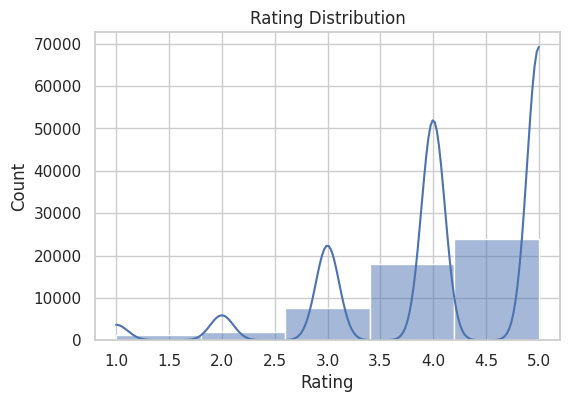

In [56]:
plt.figure(figsize=(6,4))
sns.histplot(analytics_df['Rating'], bins=5, kde=True)
plt.title("Rating Distribution")
plt.show()

### Visit Mode Distribution

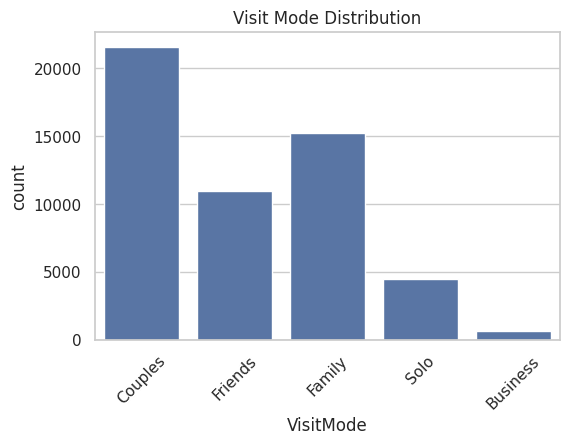

In [57]:
plt.figure(figsize=(6,4))
sns.countplot(x='VisitMode', data=analytics_df)
plt.xticks(rotation=45)
plt.title("Visit Mode Distribution")
plt.show()

### Average rating by region

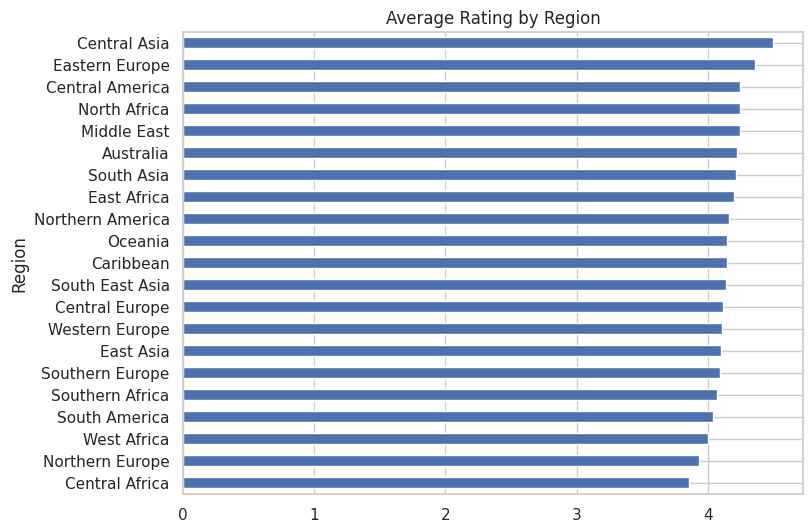

In [58]:
region_rating = analytics_df.groupby('Region')['Rating'].mean().sort_values()

region_rating.plot(kind='barh', figsize=(8,6))
plt.title("Average Rating by Region")
plt.show()

# Model Building

In [82]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

def prepare_features(df, target):

    data = df.copy()

    # ------------------------------------------------
    # KEEP ONLY BUSINESS FEATURES
    # ------------------------------------------------
    selected_features = [
        "Continent",
        "Region",
        "Country",
        "CityName",
        "VisitYear",
        "VisitMonth",
        "VisitMode",
        "AttractionType",
        "AttractionCountry",
        "AttractionCity",
        "Rating"   # keep temporarily if regression
    ]

    data = data[selected_features]

    # ------------------------------------------------
    # ENGINEER FEATURES
    # ------------------------------------------------
    data["Season"] = data["VisitMonth"].map({
        12:"Winter",1:"Winter",2:"Winter",
        3:"Spring",4:"Spring",5:"Spring",
        6:"Summer",7:"Summer",8:"Summer",
        9:"Autumn",10:"Autumn",11:"Autumn"
    })

    data["IsDomesticTrip"] = (
        data["Country"] == data["AttractionCountry"]
    ).astype(int)

    # ------------------------------------------------
    # HANDLE MISSING VALUES
    # ------------------------------------------------
    data = data.fillna("Unknown")

    # ------------------------------------------------
    # ENCODE
    # ------------------------------------------------
    from sklearn.preprocessing import LabelEncoder
    encoders = {}

    for col in data.select_dtypes(include="object").columns:
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col])
        encoders[col] = le

    X = data.drop(columns=[target])
    y = data[target]

    return X, y, encoders

In [85]:
def prepare_classification_features(df):

    import numpy as np
    from sklearn.preprocessing import LabelEncoder

    data = df.copy()

    # ------------------------------------------------
    #  CREATE NEW FEATURES INSIDE FUNCTION
    # ------------------------------------------------

    # Season
    data["Season"] = data["VisitMonth"].map({
        12:"Winter",1:"Winter",2:"Winter",
        3:"Spring",4:"Spring",5:"Spring",
        6:"Summer",7:"Summer",8:"Summer",
        9:"Autumn",10:"Autumn",11:"Autumn"
    })

    # 2 Domestic Trip
    data["IsDomesticTrip"] = (
        data["Country"] == data["AttractionCountry"]
    ).astype(int)

    # 3 Attraction Popularity (visit count)
    data["AttractionPopularity"] = (
        data.groupby("Attraction")["UserId"]
        .transform("count")
    )

    # 4 Attraction Average Rating
    data["AttractionAvgRating"] = (
        data.groupby("Attraction")["Rating"]
        .transform("mean")
    )

    # 5 Dominant Visitor Group
    data["DominantVisitorGroup"] = (
        data.groupby("Attraction")["VisitMode"]
        .transform(lambda x: x.mode()[0] if not x.mode().empty else "Unknown")
    )

    # ------------------------------------------------
    # SELECT FEATURES (Clean Business Features Only)
    # ------------------------------------------------

    selected_features = [
        "Continent",
        "Region",
        "Country",
        "CityName",
        "AttractionType",
        "AttractionCountry",
        "AttractionCity",
        "AttractionPopularity",
        "AttractionAvgRating",
        "DominantVisitorGroup",
        "VisitYear",
        "VisitMonth",
        "Season",
        "IsDomesticTrip",
        "VisitMode"  # target
    ]

    data = data[selected_features]

    # ------------------------------------------------
    # HANDLE MISSING VALUES
    # ------------------------------------------------

    # Categorical
    for col in data.select_dtypes(include="object").columns:
        data[col] = data[col].fillna("Unknown")

    # Numerical
    for col in data.select_dtypes(include=np.number).columns:
        data[col] = data[col].fillna(data[col].median())

    # ------------------------------------------------
    # ENCODE CATEGORICALS
    # ------------------------------------------------

    encoders = {}

    for col in data.select_dtypes(include="object").columns:
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col])
        encoders[col] = le

    # ------------------------------------------------
    # SPLIT X AND y
    # ------------------------------------------------

    X = data.drop(columns=["VisitMode"])
    y = data["VisitMode"]

    return X, y, encoders

In [60]:
def prepare_geo_data(df):

    geo = df.groupby(
        ["AttractionCountry", "AttractionCity"]
    ).agg({
        "Rating":"mean",
        "Attraction":"count"
    }).reset_index()

    geo = geo.rename(columns={
        "Attraction":"VisitCount",
        "Rating":"AvgRating"
    })

    return geo

In [64]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor


import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

def train_regression_models(df):

    X, y, encoders = prepare_features(df, target="Rating")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    models = {
        "XGBoost": XGBRegressor(),
        "LightGBM": LGBMRegressor(),
        "RandomForest": RandomForestRegressor()
    }

    results = []
    trained_models = {}

    for name, model in models.items():

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        mse = mean_squared_error(y_test, preds)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, preds)

        results.append({
            "Model": name,
            "RMSE": rmse,
            "R2 Score": r2
        })

        trained_models[name] = model

    comparison_df = pd.DataFrame(results).sort_values("RMSE")

    return trained_models, comparison_df, encoders, X.columns.tolist()

In [88]:
from sklearn.metrics import accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


def train_classification_models(df):

    X, y, encoders = prepare_classification_features(df)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    models = {
        "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss"),
        "LightGBM": LGBMClassifier(),
        "RandomForest": RandomForestClassifier(),
        "LogisticRegression": LogisticRegression(max_iter=1000)
    }

    results = []
    trained_models = {}

    for name, model in models.items():

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds, average="weighted")

        results.append({
            "Model": name,
            "Accuracy": acc,
            "F1 Score": f1
        })

        trained_models[name] = model

    comparison_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)

    return trained_models, comparison_df, encoders, X.columns.tolist()

# Models Comparison

In [94]:
master.columns

Index(['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitModeId',
       'AttractionId', 'Rating', 'VisitMode', 'CityId', 'CityName', 'Country',
       'Region', 'Continent', 'AttractionCityId', 'AttractionTypeId',
       'Attraction', 'AttractionAddress', 'AttractionType', 'AttractionCity',
       'AttractionCountryId', 'AttractionCountry', 'RegionId_Attraction',
       'AttractionRegion', 'ContinentId_Attraction', 'AttractionContinent'],
      dtype='object')

In [96]:
analytics_df.columns

Index(['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'AttractionId',
       'Rating', 'VisitMode', 'CityName', 'Country', 'Region', 'Continent',
       'Attraction', 'AttractionAddress', 'AttractionType', 'AttractionCity',
       'AttractionCountry', 'AttractionRegion', 'AttractionContinent',
       'VisitDate', 'VisitCount', 'UserType', 'RatingCategory',
       'IsDomesticTrip', 'IsInterContinent', 'TotalVisits', 'UserAvgRating',
       'Season', 'AttractionPopularity', 'AttractionAvgRating', 'YearMonth'],
      dtype='object')

In [83]:

reg_models, reg_comparison, reg_encoders, reg_features = train_regression_models(master)

print(reg_comparison)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002534 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 464
[LightGBM] [Info] Number of data points in the train set: 42344, number of used features: 11
[LightGBM] [Info] Start training from score 4.157425
          Model      RMSE  R2 Score
1      LightGBM  0.918917  0.103426
0       XGBoost  0.925759  0.090024
2  RandomForest  0.969025  0.002979


In [89]:
clf_models, clf_comparison, clf_encoders, clf_features = train_classification_models(master)

print(clf_comparison)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003375 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 524
[LightGBM] [Info] Number of data points in the train set: 42344, number of used features: 13
[LightGBM] [Info] Start training from score -4.453073
[LightGBM] [Info] Start training from score -0.893388
[LightGBM] [Info] Start training from score -1.249486
[LightGBM] [Info] Start training from score -1.574034
[LightGBM] [Info] Start training from score -2.462396
                Model  Accuracy  F1 Score
0             XGBoost  0.496127  0.454084
1            LightGBM  0.493765  0.444996
2        RandomForest  0.468827  0.459134
3  LogisticRegression  0.429435  0.339683


# Save Models Files

In [69]:
import os

MODEL_DIR = "models"

os.makedirs(MODEL_DIR, exist_ok=True)

In [90]:
import joblib

def save_regression_artifacts(models, encoders, features, comparison_df):

    for name, model in models.items():
        joblib.dump(model, f"{MODEL_DIR}/reg_{name}.pkl")

    joblib.dump(encoders, f"{MODEL_DIR}/reg_encoders.pkl")
    joblib.dump(features, f"{MODEL_DIR}/reg_features.pkl")

    comparison_df.to_csv(
        f"{MODEL_DIR}/regression_model_comparison.csv",
        index=False
    )

    print("Regression models saved successfully.")

In [91]:
def save_classification_artifacts(models, encoders, features, comparison_df):

    for name, model in models.items():
        joblib.dump(model, f"{MODEL_DIR}/clf_{name}.pkl")

    joblib.dump(encoders, f"{MODEL_DIR}/clf_encoders.pkl")
    joblib.dump(features, f"{MODEL_DIR}/clf_features.pkl")

    comparison_df.to_csv(
        f"{MODEL_DIR}/classification_model_comparison.csv",
        index=False
    )

    print("Classification models saved successfully.")

In [92]:
save_regression_artifacts(
    reg_models,
    reg_encoders,
    reg_features,
    reg_comparison
)

save_classification_artifacts(
    clf_models,
    clf_encoders,
    clf_features,
    clf_comparison
)

Regression models saved successfully.
Classification models saved successfully.


# Recommendation System - collaborative filtering

In [73]:
user_item = master.pivot_table(
    index="UserId",
    columns="Attraction",
    values="Rating"
).fillna(0)

In [74]:
from sklearn.metrics.pairwise import cosine_similarity

def hybrid_recommend(user_id, top_n=5):

    similarity = cosine_similarity(user_item)
    sim_df = pd.DataFrame(
        similarity,
        index=user_item.index,
        columns=user_item.index
    )

    similar_users = sim_df[user_id].sort_values(
        ascending=False
    )[1:6].index

    recs = user_item.loc[similar_users].mean()
    recs = recs.sort_values(ascending=False)

    return recs.head(top_n).index.tolist()

In [75]:
hybrid_recommend(user_id=26)

['Tegalalang Rice Terrace',
 'Balekambang Beach',
 'Coban Rondo Waterfall',
 'Goa Cina Beach',
 'Jodipan Colorful Village']

In [ ]:
# This block is to export models folder out from google collab
import shutil

shutil.make_archive("models", 'zip', "models")

'/content/models.zip'